# PyTorch Fundamentals

**Math prerequisites:** `00_math/linear_algebra.ipynb`, `00_math/calculus_chain_rule.ipynb`

**What this notebook does:** Translates every mathematical concept from `00_math/` into PyTorch code. After this notebook you will never be confused about what `loss.backward()`, `optimizer.step()`, or `requires_grad` actually do — because you'll have built them from scratch first.

**What you will be able to do:**
- Create, manipulate, and debug tensors with full confidence
- Understand autograd — what PyTorch records, what it computes, and when it fails
- Write the standard training loop and know why every line exists
- Build models with `nn.Module` and understand the parameter lifecycle
- Use GPU acceleration correctly
- Read and debug any PyTorch code

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/himanshu231204/dl-mastery/blob/main/01_foundations/pytorch_fundamentals.ipynb)

---

## Table of Contents
1. [Tensors — the core data structure](#1-tensors)
2. [Tensor Operations — bridging NumPy to PyTorch](#2-tensor-operations)
3. [Autograd — PyTorch's automatic differentiation engine](#3-autograd)
4. [Building Models with nn.Module](#4-nn-module)
5. [Loss Functions and Optimizers](#5-loss-functions-and-optimizers)
6. [The Standard Training Loop](#6-training-loop)
7. [DataLoader and Datasets](#7-dataloader)
8. [GPU Acceleration](#8-gpu)
9. [Training Dashboard — diagnosing training in real time](#9-training-dashboard)
10. [Debugging Guide — the 10 most common PyTorch errors](#10-debugging)
11. [Exercises](#11-exercises)


## Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

plt.style.use('seaborn-v0_8-whitegrid')

# Reproducibility — always set seeds at the top
torch.manual_seed(42)
np.random.seed(42)

# Device — write this once, use everywhere
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'PyTorch version: {torch.__version__}')
print(f'Device: {device}')
print(f'CUDA available: {torch.cuda.is_available()}')


PyTorch version: 2.9.0+cpu
Device: cpu
CUDA available: False


## 1. Tensors — the Core Data Structure

A **tensor** is a multi-dimensional array — the PyTorch equivalent of a NumPy `ndarray`. The critical difference: tensors can live on GPU and support automatic differentiation.

### The four things to always check about a tensor

```python
t.shape    # dimensions — most common source of bugs
t.dtype    # float32 / float16 / int64 / bool — mismatches cause silent errors
t.device   # cpu / cuda:0 — operations between different devices crash
t.requires_grad  # True = tracked by autograd, False = not
```

**Golden rule for debugging:** Before any operation, print the shape of every input tensor. 90% of PyTorch bugs are shape mismatches.


In [2]:
# ── Creating tensors ─────────────────────────────────────────────────────────
print('=== Tensor creation ===')

# From Python data
t1 = torch.tensor([1.0, 2.0, 3.0])
t2 = torch.tensor([[1, 2, 3], [4, 5, 6]], dtype=torch.float32)

# Built-in constructors
zeros  = torch.zeros(3, 4)
ones   = torch.ones(2, 3)
rand_n = torch.randn(4, 5)        # standard normal
eye    = torch.eye(3)             # identity
arange = torch.arange(0, 10, 2)  # [0, 2, 4, 6, 8]

print(f't1:       shape={t1.shape}  dtype={t1.dtype}  device={t1.device}')
print(f't2:       shape={t2.shape}  dtype={t2.dtype}')
print(f'zeros:    shape={zeros.shape}')
print(f'rand_n:   shape={rand_n.shape}')
print(f'arange:   {arange}')

# From NumPy — two ways with different semantics
arr = np.array([1.0, 2.0, 3.0])
t_shared = torch.from_numpy(arr)   # SHARES memory — changing arr changes t_shared!
t_copy   = torch.tensor(arr)       # copies — safe

arr[0] = 99.0
print(f'\nAfter modifying arr:')
print(f'  t_shared[0] = {t_shared[0].item()}  (changed! — shared memory)')
print(f'  t_copy[0]   = {t_copy[0].item()}    (unchanged — copied)')
print('Use torch.tensor(arr) unless you explicitly want shared memory.')


=== Tensor creation ===
t1:       shape=torch.Size([3])  dtype=torch.float32  device=cpu
t2:       shape=torch.Size([2, 3])  dtype=torch.float32
zeros:    shape=torch.Size([3, 4])
rand_n:   shape=torch.Size([4, 5])
arange:   tensor([0, 2, 4, 6, 8])

After modifying arr:
  t_shared[0] = 99.0  (changed! — shared memory)
  t_copy[0]   = 1.0    (unchanged — copied)
Use torch.tensor(arr) unless you explicitly want shared memory.


In [3]:
# ── Tensor attributes and inspection ─────────────────────────────────────────
t = torch.randn(3, 4, 5)

print(f'shape:       {t.shape}       <- torch.Size, behaves like a tuple')
print(f'ndim:        {t.ndim}')
print(f'numel():     {t.numel()}     <- total number of elements')
print(f'dtype:       {t.dtype}')
print(f'device:      {t.device}')
print(f'requires_grad:{t.requires_grad}')

# Accessing elements
t2d = torch.tensor([[10., 20., 30.], [40., 50., 60.]])
print(f'\nt2d[0]:      {t2d[0]}')
print(f't2d[:, 1]:   {t2d[:, 1]}')
print(f't2d[1, 2]:   {t2d[1, 2].item()}')
print('.item() converts a 0-dim tensor to a Python scalar — use for printing losses')


shape:       torch.Size([3, 4, 5])       <- torch.Size, behaves like a tuple
ndim:        3
numel():     60     <- total number of elements
dtype:       torch.float32
device:      cpu
requires_grad:False

t2d[0]:      tensor([10., 20., 30.])
t2d[:, 1]:   tensor([20., 50.])
t2d[1, 2]:   60.0
.item() converts a 0-dim tensor to a Python scalar — use for printing losses


In [4]:
# ── Reshaping — the most important operation for debugging ────────────────────
t = torch.arange(24, dtype=torch.float32)
print(f'Original: {t.shape}')

# reshape vs view — both return (3,8) but with different constraints
r1 = t.reshape(3, 8)         # safe — works even on non-contiguous tensors
r2 = t.view(3, 8)            # fast — requires contiguous memory
r3 = t.reshape(3, -1)        # -1 means 'infer this dimension'
r4 = t.reshape(2, 3, 4)      # 3D

print(f'reshape(3,8):  {r1.shape}')
print(f'reshape(3,-1): {r3.shape}  (-1 inferred as 8)')
print(f'reshape(2,3,4):{r4.shape}')

# squeeze / unsqueeze — critical for batch dimension handling
v = torch.randn(5)
print(f'\nv.shape:           {v.shape}')
print(f'unsqueeze(0).shape:{v.unsqueeze(0).shape}  <- add batch dim')
print(f'unsqueeze(1).shape:{v.unsqueeze(1).shape}  <- add feature dim')

# The (n,) vs (n,1) vs (1,n) distinction matters for broadcasting!
a = torch.randn(5)       # shape (5,)
b = torch.randn(5, 1)    # shape (5, 1)
c = torch.randn(1, 5)    # shape (1, 5)
print(f'\n(a + c).shape: {(a + c).shape}  <- broadcast: (5,) + (1,5) -> (1,5) + (1,5)')
print(f'(b + c).shape: {(b + c).shape}  <- broadcast: (5,1) + (1,5) -> (5,5)')
print('Broadcasting creates new dimensions — understand shapes before assuming!')


Original: torch.Size([24])
reshape(3,8):  torch.Size([3, 8])
reshape(3,-1): torch.Size([3, 8])  (-1 inferred as 8)
reshape(2,3,4):torch.Size([2, 3, 4])

v.shape:           torch.Size([5])
unsqueeze(0).shape:torch.Size([1, 5])  <- add batch dim
unsqueeze(1).shape:torch.Size([5, 1])  <- add feature dim

(a + c).shape: torch.Size([1, 5])  <- broadcast: (5,) + (1,5) -> (1,5) + (1,5)
(b + c).shape: torch.Size([5, 5])  <- broadcast: (5,1) + (1,5) -> (5,5)
Broadcasting creates new dimensions — understand shapes before assuming!


## 2. Tensor Operations — Bridging NumPy to PyTorch

Every NumPy operation has a PyTorch equivalent. The key differences:

| NumPy | PyTorch | Note |
|---|---|---|
| `np.dot(a,b)` / `a @ b` | `torch.matmul(a,b)` / `a @ b` | Both support batched |
| `a.T` | `a.T` or `a.transpose(0,1)` | `.T` only for 2D |
| `np.sum(a, axis=0)` | `a.sum(dim=0)` | `dim` not `axis` |
| `np.einsum` | `torch.einsum` | Identical syntax |
| `np.maximum(0, x)` | `F.relu(x)` or `x.clamp(min=0)` | |
| `np.exp(x)` | `torch.exp(x)` | |
| `a[a > 0]` | `a[a > 0]` | Boolean indexing works |

**Critical difference:** PyTorch distinguishes in-place operations with a trailing `_`:
- `t.add_(1)` modifies `t` in-place
- `t.add(1)` returns a new tensor

In-place operations on tensors that require gradients will cause autograd errors.


In [5]:
# ── Matrix operations — connect to 00_math/linear_algebra ────────────────────
A = torch.randn(3, 4)
B = torch.randn(4, 2)

print('=== Matrix operations ===')
print(f'A @ B:           {(A @ B).shape}       (matmul)')
print(f'torch.matmul:    {torch.matmul(A, B).shape}')
print(f'A.T:             {A.T.shape}            (transpose)')

# Reductions with keepdim
x = torch.randn(4, 5)
print(f'\nx.sum():         {x.sum().shape}   (scalar)')
print(f'x.sum(dim=0):    {x.sum(dim=0).shape}    (sum over rows)')
print(f'x.sum(dim=1):    {x.sum(dim=1).shape}    (sum over cols)')
print(f'x.sum(dim=1, keepdim=True): {x.sum(dim=1, keepdim=True).shape}  (keep dim for broadcasting)')

# Einsum — identical to NumPy
Q = torch.randn(2, 6, 8, 16)  # (batch, heads, seq, head_dim)
K = torch.randn(2, 6, 8, 16)
scores = torch.einsum('bhid,bhjd->bhij', Q, K)
print(f'\nMulti-head attention scores via einsum: {scores.shape}')


=== Matrix operations ===
A @ B:           torch.Size([3, 2])       (matmul)
torch.matmul:    torch.Size([3, 2])
A.T:             torch.Size([4, 3])            (transpose)

x.sum():         torch.Size([])   (scalar)
x.sum(dim=0):    torch.Size([5])    (sum over rows)
x.sum(dim=1):    torch.Size([4])    (sum over cols)
x.sum(dim=1, keepdim=True): torch.Size([4, 1])  (keep dim for broadcasting)

Multi-head attention scores via einsum: torch.Size([2, 6, 8, 8])


In [6]:
# ── Common mistakes with dtypes ───────────────────────────────────────────────
print('=== dtype issues ===')

# Float vs int mismatch
x_float = torch.tensor([1.0, 2.0, 3.0])    # float32
x_int   = torch.tensor([1, 2, 3])           # int64

print(f'x_float dtype: {x_float.dtype}')
print(f'x_int   dtype: {x_int.dtype}')

# Casting
x_cast = x_int.float()       # int64 -> float32
x_cast2 = x_float.long()     # float32 -> int64
print(f'x_int.float(): {x_cast.dtype}')
print(f'x_float.long(): {x_cast2.dtype}')

# nn.CrossEntropyLoss expects: logits float32, targets int64
logits  = torch.randn(4, 3)              # (batch, num_classes) float32
targets = torch.tensor([0, 2, 1, 0])    # (batch,) int64
loss_fn = nn.CrossEntropyLoss()
loss    = loss_fn(logits, targets)
print(f'\nCrossEntropyLoss: logits {logits.dtype} + targets {targets.dtype} -> loss {loss.item():.4f}')

# Common error: targets are float
try:
    wrong_targets = torch.tensor([0.0, 2.0, 1.0, 0.0])  # float!
    loss_fn(logits, wrong_targets)
except RuntimeError as e:
    print(f'\nExpected error (targets must be long): {str(e)[:80]}...')
    print('Fix: targets.long() or use torch.tensor([...], dtype=torch.long)')


=== dtype issues ===
x_float dtype: torch.float32
x_int   dtype: torch.int64
x_int.float(): torch.float32
x_float.long(): torch.int64

CrossEntropyLoss: logits torch.float32 + targets torch.int64 -> loss 0.8024

Expected error (targets must be long): expected scalar type Long but found Float...
Fix: targets.long() or use torch.tensor([...], dtype=torch.long)


## 3. Autograd — PyTorch's Automatic Differentiation Engine

Autograd implements **reverse-mode automatic differentiation** — the chain rule applied programmatically to a recorded computation graph (see `00_math/calculus_chain_rule.ipynb`).

### How it works

1. **Forward pass:** PyTorch records every operation on tensors with `requires_grad=True`    into a directed acyclic graph (DAG). Each node stores its output and a backward function.

2. **`loss.backward()`:** Traverses the DAG in reverse, calling each node's backward function    and accumulating gradients into `.grad` attributes using the chain rule.

3. **`optimizer.step()`:** Uses the accumulated `.grad` values to update parameters.

### The gradient lifecycle

```
parameters defined (requires_grad=True)
        ↓
optimizer.zero_grad()     ← MUST do before each backward — gradients accumulate!
        ↓
output = model(input)     ← forward pass — builds computation graph
        ↓
loss = criterion(output, target)
        ↓
loss.backward()           ← backward pass — fills .grad for all parameters
        ↓
optimizer.step()          ← w = w - lr * w.grad
        ↓
(repeat)
```


In [7]:
# ── Autograd from scratch — see exactly what PyTorch computes ────────────────
print('=== Autograd walkthrough ===')

# Create a simple computation: L = sum((W @ x + b)^2)
torch.manual_seed(0)
W = torch.randn(3, 4, requires_grad=True)   # parameter — tracked
b = torch.randn(3,    requires_grad=True)   # parameter — tracked
x = torch.randn(4)                          # input — NOT tracked

# Forward pass
z    = W @ x + b           # linear layer
loss = (z ** 2).sum()      # squared L2 norm

print(f'W.requires_grad:    {W.requires_grad}')
print(f'x.requires_grad:    {x.requires_grad}  (input, not tracked)')
print(f'z.requires_grad:    {z.requires_grad}  (inherited from W, b)')
print(f'loss.requires_grad: {loss.requires_grad}')
print(f'\nloss.grad_fn: {loss.grad_fn}  <- knows how to backprop through sum')
print(f'z.grad_fn:    {z.grad_fn}    <- knows how to backprop through AddBackward')

# Backward pass
loss.backward()

print(f'\nAfter loss.backward():')
print(f'W.grad shape: {W.grad.shape}  (matches W shape ✓)')
print(f'b.grad shape: {b.grad.shape}  (matches b shape ✓)')
print(f'x.grad:       {x.grad}  (None — not tracked)')

# Verify analytically: dL/dW = 2z @ x^T
with torch.no_grad():
    dL_dW_anal = 2 * torch.outer(z, x)
print(f'\nAnalytical dL/dW matches autograd: {torch.allclose(W.grad, dL_dW_anal, atol=1e-5)}')


=== Autograd walkthrough ===
W.requires_grad:    True
x.requires_grad:    False  (input, not tracked)
z.requires_grad:    True  (inherited from W, b)
loss.requires_grad: True

loss.grad_fn: <SumBackward0 object at 0x79d3b74cb880>  <- knows how to backprop through sum
z.grad_fn:    <AddBackward0 object at 0x79d3b74cb880>    <- knows how to backprop through AddBackward

After loss.backward():
W.grad shape: torch.Size([3, 4])  (matches W shape ✓)
b.grad shape: torch.Size([3])  (matches b shape ✓)
x.grad:       None  (None — not tracked)

Analytical dL/dW matches autograd: True


In [8]:
# ── Gradient accumulation and zeroing ────────────────────────────────────────
print('=== CRITICAL: gradients accumulate! ===')

W2 = torch.randn(2, 3, requires_grad=True)
x2 = torch.randn(3)

# Run backward twice without zeroing
loss1 = (W2 @ x2).sum()
loss1.backward()
print(f'After 1st backward, W2.grad:')
print(W2.grad)

loss2 = (W2 @ x2).sum()
loss2.backward()  # gradient ADDS to existing .grad!
print(f'After 2nd backward WITHOUT zeroing, W2.grad:')
print(W2.grad)
print('^ This is 2x the correct gradient — a common bug!')

# Correct: zero before each backward
W2.grad.zero_()   # in-place zero
loss3 = (W2 @ x2).sum()
loss3.backward()
print(f'After zero_() + backward, W2.grad:')
print(W2.grad)
print('^ Back to correct value')

print('\nIn training loops: ALWAYS call optimizer.zero_grad() before loss.backward()')


=== CRITICAL: gradients accumulate! ===
After 1st backward, W2.grad:
tensor([[ 1.2638, -1.2904, -0.7911],
        [ 1.2638, -1.2904, -0.7911]])
After 2nd backward WITHOUT zeroing, W2.grad:
tensor([[ 2.5276, -2.5809, -1.5822],
        [ 2.5276, -2.5809, -1.5822]])
^ This is 2x the correct gradient — a common bug!
After zero_() + backward, W2.grad:
tensor([[ 1.2638, -1.2904, -0.7911],
        [ 1.2638, -1.2904, -0.7911]])
^ Back to correct value

In training loops: ALWAYS call optimizer.zero_grad() before loss.backward()


In [9]:
# ── no_grad and detach — stopping gradient tracking ──────────────────────────
print('=== torch.no_grad() and .detach() ===')

model_param = torch.randn(3, 3, requires_grad=True)

# torch.no_grad() — context manager, disables gradient tracking
# Use for: inference, validation, evaluation, any computation where you don't need gradients
with torch.no_grad():
    output = model_param @ torch.randn(3)
    print(f'Inside no_grad — output.requires_grad: {output.requires_grad}  (False)')

# .detach() — creates a new tensor sharing data but detached from computation graph
# Use for: converting model output to numpy, logging loss values, using tensor as target
y_pred = model_param @ torch.randn(3)
y_detached = y_pred.detach()
print(f'y_pred.requires_grad:    {y_pred.requires_grad}')
print(f'y_detached.requires_grad:{y_detached.requires_grad}')

# NEVER do this (wrong):
# loss_value = loss.numpy()  <- will error if requires_grad=True
# DO this:
# loss_value = loss.detach().numpy()
# OR: loss.item()  <- for scalars
print('\nTo convert a gradient tensor to numpy: t.detach().numpy()')
print('To log a scalar loss: loss.item()')


=== torch.no_grad() and .detach() ===
Inside no_grad — output.requires_grad: False  (False)
y_pred.requires_grad:    True
y_detached.requires_grad:False

To convert a gradient tensor to numpy: t.detach().numpy()
To log a scalar loss: loss.item()


## 4. Building Models with nn.Module

Every neural network in PyTorch is a subclass of `nn.Module`. Understanding `nn.Module` means understanding:

1. **`__init__`** — define all sub-modules and parameters (called once)
2. **`forward`** — define the computation (called every forward pass)
3. **`.parameters()`** — returns all learnable tensors (used by optimizer)
4. **`.train()` / `.eval()`** — switches behaviour of BatchNorm and Dropout
5. **`.state_dict()`** — serialises all parameters (used for saving)

### What `nn.Linear(in, out)` actually does

```python
# This:
y = nn.Linear(4, 3)(x)

# Is exactly this:
W = torch.randn(3, 4) * sqrt(1/4)   # Xavier init
b = torch.zeros(3)
y = x @ W.T + b
```


In [10]:
# ── Build three versions of the same network ─────────────────────────────────
# to see what nn.Module hides

# ── Version 1: raw tensors (no nn.Module) ────────────────────────────────────
class MLPRaw:
    def __init__(self, d_in, d_h, d_out):
        k = (2.0 / d_in) ** 0.5  # He init std
        self.W1 = torch.randn(d_h, d_in)  * k; self.W1.requires_grad_(True)
        self.b1 = torch.zeros(d_h);             self.b1.requires_grad_(True)
        self.W2 = torch.randn(d_out, d_h) * (2.0/d_h)**0.5; self.W2.requires_grad_(True)
        self.b2 = torch.zeros(d_out);            self.b2.requires_grad_(True)

    def forward(self, x):
        h = F.relu(x @ self.W1.T + self.b1)
        return h @ self.W2.T + self.b2

    def parameters(self):
        return [self.W1, self.b1, self.W2, self.b2]

# ── Version 2: nn.Module (production style) ──────────────────────────────────
class MLP(nn.Module):
    def __init__(self, d_in, d_h, d_out):
        super().__init__()
        self.fc1 = nn.Linear(d_in, d_h)
        self.fc2 = nn.Linear(d_h, d_out)

    def forward(self, x):
        h = F.relu(self.fc1(x))
        return self.fc2(h)

# ── Version 3: nn.Sequential (for simple chains) ─────────────────────────────
mlp_seq = nn.Sequential(
    nn.Linear(4, 8),
    nn.ReLU(),
    nn.Linear(8, 3),
)

# Compare
x_test = torch.randn(5, 4)   # batch=5, features=4

mlp_raw = MLPRaw(4, 8, 3)
mlp_mod = MLP(4, 8, 3)

out_raw = mlp_raw.forward(x_test)
out_mod = mlp_mod(x_test)          # nn.Module: calling instance calls forward()
out_seq = mlp_seq(x_test)

print('All three produce the same output shape:')
print(f'  MLPRaw:         {out_raw.shape}')
print(f'  MLP (Module):   {out_mod.shape}')
print(f'  Sequential:     {out_seq.shape}')


All three produce the same output shape:
  MLPRaw:         torch.Size([5, 3])
  MLP (Module):   torch.Size([5, 3])
  Sequential:     torch.Size([5, 3])


In [11]:
# ── nn.Module internals ───────────────────────────────────────────────────────
model = MLP(4, 8, 3)

print('=== Model internals ===')
print(model)
print()

# Count parameters
total      = sum(p.numel() for p in model.parameters())
trainable  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params:     {total:,}')
print(f'Trainable params: {trainable:,}')

# Inspect individual parameters
print('\nParameter breakdown:')
for name, param in model.named_parameters():
    print(f'  {name:<15} shape={str(param.shape):<15} requires_grad={param.requires_grad}')

# state_dict — everything needed to save/restore the model
print('\nstate_dict keys:')
for k, v in model.state_dict().items():
    print(f'  {k:<20} {v.shape}')


=== Model internals ===
MLP(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=3, bias=True)
)

Total params:     67
Trainable params: 67

Parameter breakdown:
  fc1.weight      shape=torch.Size([8, 4]) requires_grad=True
  fc1.bias        shape=torch.Size([8]) requires_grad=True
  fc2.weight      shape=torch.Size([3, 8]) requires_grad=True
  fc2.bias        shape=torch.Size([3]) requires_grad=True

state_dict keys:
  fc1.weight           torch.Size([8, 4])
  fc1.bias             torch.Size([8])
  fc2.weight           torch.Size([3, 8])
  fc2.bias             torch.Size([3])


In [12]:
# ── train() vs eval() mode ───────────────────────────────────────────────────
print('=== train() vs eval() mode ===')

# Model with Dropout and BatchNorm
class ModelWithBNDrop(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(8, 16)
        self.bn  = nn.BatchNorm1d(16)
        self.drop= nn.Dropout(p=0.5)
        self.fc2 = nn.Linear(16, 4)

    def forward(self, x):
        return self.fc2(self.drop(F.relu(self.bn(self.fc1(x)))))

m = ModelWithBNDrop()
x_bn = torch.randn(10, 8)

# In train mode: dropout randomly drops neurons, BatchNorm uses batch stats
m.train()
out1 = m(x_bn)
out2 = m(x_bn)  # different! dropout is stochastic
print(f'Train mode — same input, two runs differ: {not torch.allclose(out1, out2)}')

# In eval mode: dropout disabled, BatchNorm uses running stats
m.eval()
with torch.no_grad():
    out3 = m(x_bn)
    out4 = m(x_bn)  # identical!
print(f'Eval mode  — same input, two runs match: {torch.allclose(out3, out4)}')

print('\nALWAYS call model.eval() before validation/inference')
print('ALWAYS call model.train() before training')


=== train() vs eval() mode ===
Train mode — same input, two runs differ: True
Eval mode  — same input, two runs match: True

ALWAYS call model.eval() before validation/inference
ALWAYS call model.train() before training


## 5. Loss Functions and Optimizers

### Loss Functions — connect to probability theory (see `00_math/probability_distributions.ipynb`)

| Loss | Formula | Use when | Distribution assumption |
|---|---|---|---|
| `nn.CrossEntropyLoss` | $-\log p_{y_i}$ | Multi-class classification | Categorical |
| `nn.BCEWithLogitsLoss` | $-y\log\sigma(z) - (1-y)\log(1-\sigma(z))$ | Binary / multi-label | Bernoulli |
| `nn.MSELoss` | $\frac{1}{n}\sum(y-\hat{y})^2$ | Regression | Gaussian noise |
| `nn.L1Loss` | $\frac{1}{n}\sum|y-\hat{y}|$ | Regression with outliers | Laplace noise |
| `nn.KLDivLoss` | $\sum p \log(p/q)$ | VAE regularisation, distillation | — |

### Optimizers — connect to matrix calculus (see `00_math/matrix_calculus.ipynb`)

| Optimizer | Update rule | Best for |
|---|---|---|
| `SGD` | $w \leftarrow w - \alpha g$ | Simple baseline, fine-tuning |
| `SGD+momentum` | $v = \beta v + g$, $w \leftarrow w - \alpha v$ | CV tasks |
| `Adam` | Adaptive per-parameter lr via 1st/2nd moments | Default choice |
| `AdamW` | Adam + decoupled weight decay | Transformers |
| `RMSprop` | Divide by running avg of squared gradients | RNNs |


In [13]:
# ── Loss function deep dives ──────────────────────────────────────────────────
print('=== CrossEntropyLoss (most important to understand) ===')
print('Expects: logits float32 (NOT softmax output!), targets int64')
print('Computes: -log(softmax(logits)[target]) internally')
print()

logits  = torch.tensor([[2.0, 1.0, 0.1], [0.5, 2.5, 0.3]])  # (2, 3)
targets = torch.tensor([0, 1])                                 # (2,) int64

ce_loss = nn.CrossEntropyLoss()
loss_val = ce_loss(logits, targets)

# Manual verification
probs  = torch.softmax(logits, dim=1)
manual = -torch.log(probs[torch.arange(2), targets]).mean()

print(f'CrossEntropyLoss: {loss_val.item():.6f}')
print(f'Manual -log(p_y): {manual.item():.6f}')
print(f'Match: {torch.isclose(loss_val, manual)}')
print(f'\nProbabilities:\n{probs.detach().numpy().round(4)}')

# Class weights for imbalanced data
weights = torch.tensor([0.5, 2.0, 1.0])  # upweight class 1
ce_weighted = nn.CrossEntropyLoss(weight=weights)
print(f'Weighted loss: {ce_weighted(logits, targets).item():.6f}')


=== CrossEntropyLoss (most important to understand) ===
Expects: logits float32 (NOT softmax output!), targets int64
Computes: -log(softmax(logits)[target]) internally

CrossEntropyLoss: 0.318540
Manual -log(p_y): 0.318540
Match: True

Probabilities:
[[0.659  0.2424 0.0986]
 [0.1086 0.8025 0.0889]]
Weighted loss: 0.259446


=== Optimizer comparison on a simple regression task ===


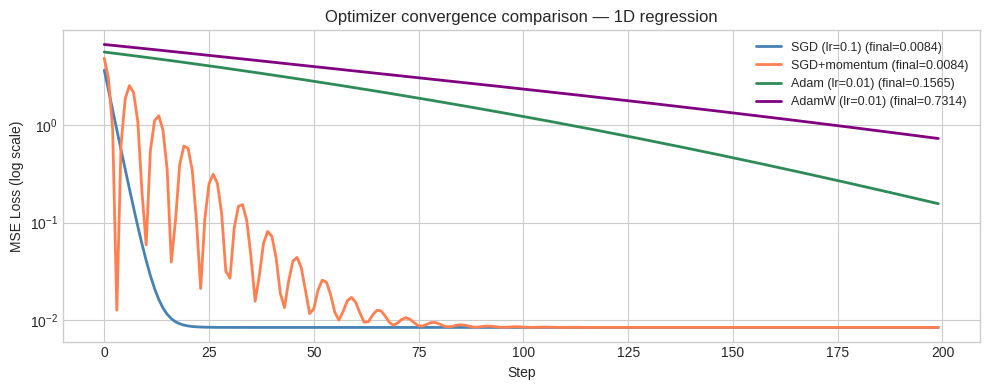

In [14]:
# ── Optimizer comparison ─────────────────────────────────────────────────────
print('=== Optimizer comparison on a simple regression task ===')

# Simple 1D regression: y = 2x + 1 + noise
torch.manual_seed(0)
X_reg = torch.randn(100, 1)
y_reg = 2 * X_reg + 1 + 0.1 * torch.randn(100, 1)

def make_model():
    return nn.Linear(1, 1)

optimizers_config = [
    ('SGD (lr=0.1)',        lambda m: optim.SGD(m.parameters(), lr=0.1)),
    ('SGD+momentum',        lambda m: optim.SGD(m.parameters(), lr=0.1, momentum=0.9)),
    ('Adam (lr=0.01)',      lambda m: optim.Adam(m.parameters(), lr=0.01)),
    ('AdamW (lr=0.01)',     lambda m: optim.AdamW(m.parameters(), lr=0.01, weight_decay=0.01)),
]

fig, ax = plt.subplots(figsize=(10, 4))
colors_opt = ['steelblue', 'coral', 'seagreen', 'purple']

for (name, opt_fn), color in zip(optimizers_config, colors_opt):
    model_opt = make_model()
    optimizer = opt_fn(model_opt)
    criterion = nn.MSELoss()
    losses_opt = []

    for step in range(200):
        optimizer.zero_grad()
        pred = model_opt(X_reg)
        loss = criterion(pred, y_reg)
        loss.backward()
        optimizer.step()
        losses_opt.append(loss.item())

    ax.semilogy(losses_opt, color=color, linewidth=2,
                label=f'{name} (final={losses_opt[-1]:.4f})')

ax.set_title('Optimizer convergence comparison — 1D regression')
ax.set_xlabel('Step'); ax.set_ylabel('MSE Loss (log scale)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## 6. The Standard Training Loop

Every PyTorch training loop has this exact structure. Every line exists for a reason.

```python
model.train()              # 1. Set training mode (enables dropout, BatchNorm uses batch stats)
optimizer.zero_grad()      # 2. Clear gradients (they accumulate — see Section 3)
output = model(X)          # 3. Forward pass — builds computation graph
loss   = criterion(output, y)  # 4. Compute loss
loss.backward()            # 5. Backward pass — fills .grad for all parameters
torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # 6. Clip gradients (prevents exploding)
optimizer.step()           # 7. Update parameters: w = w - lr * w.grad
```

**Why gradient clipping?** If gradients explode (e.g., in deep networks or RNNs), a single step can overshoot wildly and destabilise training. Clipping rescales the gradient vector to have a maximum L2 norm of 1.0.


In [15]:
# ── Complete, production-grade training loop ─────────────────────────────────
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Data
X_sk, y_sk = make_classification(n_samples=1000, n_features=20,
                                   n_informative=10, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X_sk, y_sk, test_size=0.2, random_state=42)
scaler = StandardScaler(); X_tr = scaler.fit_transform(X_tr); X_te = scaler.transform(X_te)

# Convert to tensors
X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
X_te_t = torch.tensor(X_te, dtype=torch.float32)
y_tr_t = torch.tensor(y_tr, dtype=torch.long)
y_te_t = torch.tensor(y_te, dtype=torch.long)

# Model, loss, optimizer
torch.manual_seed(42)
model     = nn.Sequential(
    nn.Linear(20, 64), nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(64, 32), nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(32, 2)
).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

# DataLoaders
train_ds = TensorDataset(X_tr_t, y_tr_t)
val_ds   = TensorDataset(X_te_t, y_te_t)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}

def run_epoch(loader, training=True):
    if training: model.train()
    else:        model.eval()
    total_loss, correct, total = 0.0, 0, 0

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            if training: optimizer.zero_grad()          # step 2
            logits = model(X_batch)                     # step 3
            loss   = criterion(logits, y_batch)         # step 4
            if training:
                loss.backward()                         # step 5
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # step 6
                optimizer.step()                        # step 7
            total_loss += loss.item() * len(X_batch)
            correct    += (logits.argmax(1) == y_batch).sum().item()
            total      += len(X_batch)

    return total_loss / total, correct / total

N_EPOCHS = 50
for epoch in range(1, N_EPOCHS+1):
    tr_loss, tr_acc = run_epoch(train_loader, training=True)
    vl_loss, vl_acc = run_epoch(val_loader,   training=False)
    scheduler.step()
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)
    history['lr'].append(scheduler.get_last_lr()[0])
    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d}  train_loss={tr_loss:.4f}  val_loss={vl_loss:.4f}  '
              f'train_acc={tr_acc:.4f}  val_acc={vl_acc:.4f}')


Epoch  10  train_loss=0.2845  val_loss=0.2914  train_acc=0.8825  val_acc=0.8850
Epoch  20  train_loss=0.1900  val_loss=0.2239  train_acc=0.9225  val_acc=0.9150
Epoch  30  train_loss=0.1543  val_loss=0.2187  train_acc=0.9450  val_acc=0.9200
Epoch  40  train_loss=0.1316  val_loss=0.2045  train_acc=0.9475  val_acc=0.9200
Epoch  50  train_loss=0.1125  val_loss=0.2045  train_acc=0.9513  val_acc=0.9200


## 7. DataLoader and Datasets

In [16]:
# ── DataLoader patterns ───────────────────────────────────────────────────────
print('=== DataLoader patterns ===')

# 1. TensorDataset — for data already in tensors (most common)
X_d = torch.randn(200, 10)
y_d = torch.randint(0, 3, (200,))
ds  = TensorDataset(X_d, y_d)
loader = DataLoader(ds, batch_size=32, shuffle=True, drop_last=True)
print(f'Dataset size: {len(ds)}')
print(f'Batches per epoch: {len(loader)}  (200/32 = 6.25 -> 6 with drop_last=True)')

# Peek at one batch
X_batch, y_batch = next(iter(loader))
print(f'Batch X: {X_batch.shape}  y: {y_batch.shape}')

# 2. Custom Dataset — for custom data loading
from torch.utils.data import Dataset

class CustomDataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x_sample = self.X[idx]
        if self.transform:
            x_sample = self.transform(x_sample)
        return x_sample, self.y[idx]

custom_ds = CustomDataset(X_d, y_d)
print(f'\nCustomDataset size: {len(custom_ds)}')
print(f'One sample shape: {custom_ds[0][0].shape}')

# Train/val split
train_size = int(0.8 * len(custom_ds))
val_size   = len(custom_ds) - train_size
train_set, val_set = random_split(custom_ds, [train_size, val_size],
                                   generator=torch.Generator().manual_seed(42))
print(f'Train: {len(train_set)}  Val: {len(val_set)}')


=== DataLoader patterns ===
Dataset size: 200
Batches per epoch: 6  (200/32 = 6.25 -> 6 with drop_last=True)
Batch X: torch.Size([32, 10])  y: torch.Size([32])

CustomDataset size: 200
One sample shape: torch.Size([10])
Train: 160  Val: 40


## 8. GPU Acceleration

In [17]:
# ── GPU best practices ───────────────────────────────────────────────────────
print('=== GPU best practices ===')

print('device =', device)

# Pattern 1: Move model to device once
model_gpu = nn.Linear(100, 50).to(device)
print(f'Model on: {next(model_gpu.parameters()).device}')

# Pattern 2: Move data to device in the training loop (NOT beforehand)
# BAD:  X_all = X_all.to(device)  <- moves entire dataset, may run out of GPU memory
# GOOD: X_batch = X_batch.to(device)  <- move each batch in the loop
print('\nCorrect pattern (move batch in loop, not whole dataset):')
print('  for X_batch, y_batch in loader:')
print('      X_batch = X_batch.to(device)')
print('      y_batch = y_batch.to(device)')

# Pattern 3: Pinned memory for faster CPU->GPU transfer
loader_gpu = DataLoader(train_ds, batch_size=64, shuffle=True,
                        pin_memory=(device.type == 'cuda'),
                        num_workers=0)  # 0 for notebook, 2-4 for scripts
print(f'\npin_memory={loader_gpu.pin_memory}')

# Pattern 4: Mixed precision training (faster on modern GPUs)
print('\nFor GPU training with mixed precision (float16/float32):')
print('  scaler = torch.cuda.amp.GradScaler()')
print('  with torch.autocast(device_type="cuda"):')
print('      loss = criterion(model(X), y)')
print('  scaler.scale(loss).backward()')
print('  scaler.step(optimizer)')
print('  scaler.update()')


=== GPU best practices ===
device = cpu
Model on: cpu

Correct pattern (move batch in loop, not whole dataset):
  for X_batch, y_batch in loader:
      X_batch = X_batch.to(device)
      y_batch = y_batch.to(device)

pin_memory=False

For GPU training with mixed precision (float16/float32):
  scaler = torch.cuda.amp.GradScaler()
  with torch.autocast(device_type="cuda"):
      loss = criterion(model(X), y)
  scaler.scale(loss).backward()
  scaler.step(optimizer)
  scaler.update()


## 9. Training Dashboard — Diagnosing Training in Real Time

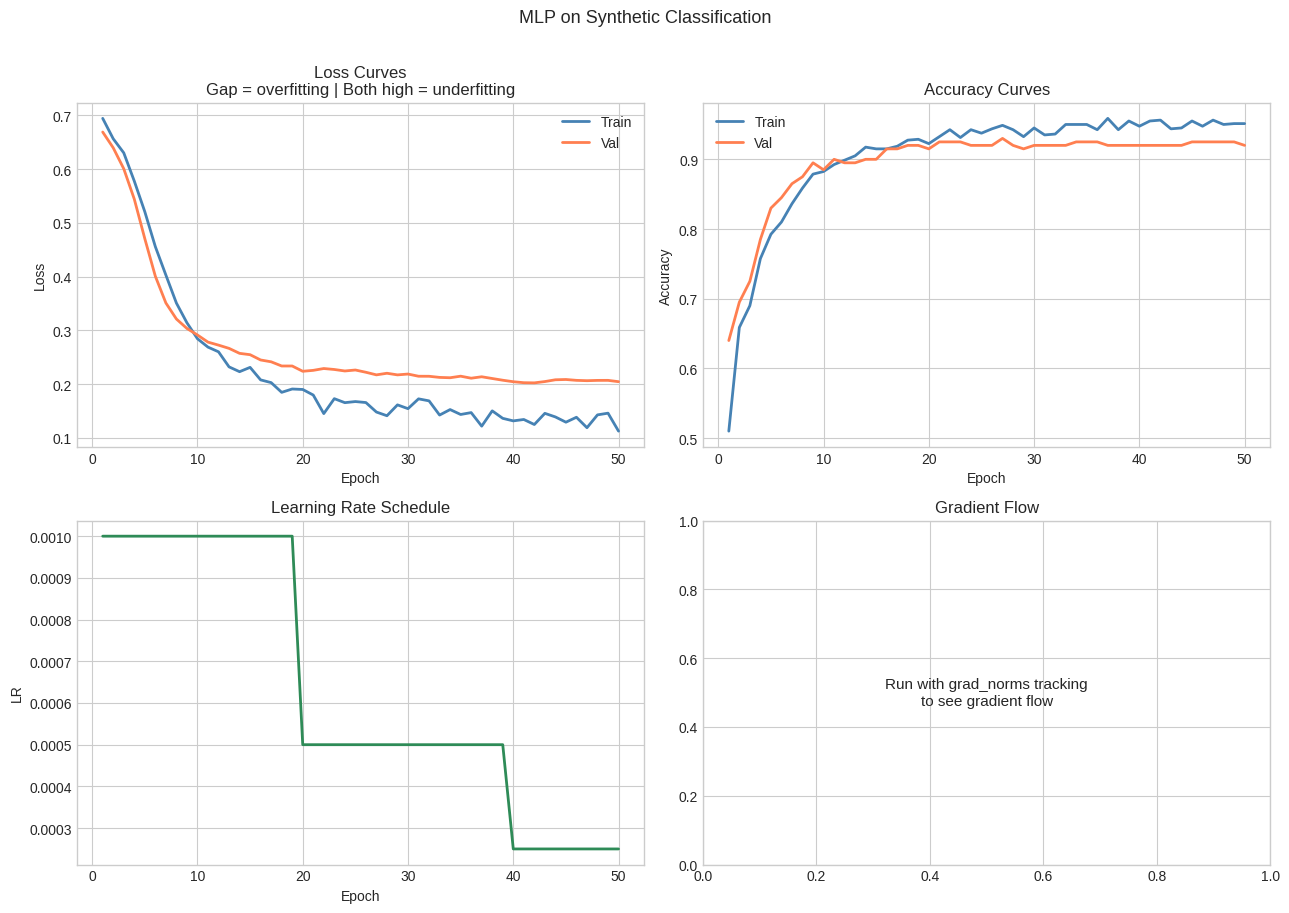

In [18]:
# ── 4-panel training dashboard (use after every training run) ────────────────
def plot_training_dashboard(history, title='Training Dashboard'):
    """
    4-panel diagnostic plot for every training run.
    Panel 1: Loss curves  (train vs val)
    Panel 2: Accuracy curves
    Panel 3: Learning rate schedule
    Panel 4: Gradient flow — mean gradient norm per named parameter

    HOW TO READ:
    - Train loss >> Val loss:  overfitting — add dropout/weight decay or more data
    - Both losses plateau high: underfitting — increase model capacity or lr
    - Val loss spikes then drops: lr too high — use scheduler
    - Gradient norms near 0 in early layers: vanishing gradient
    """
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))

    # Loss curves
    ep = range(1, len(history['train_loss'])+1)
    axes[0,0].plot(ep, history['train_loss'], color='steelblue', linewidth=2, label='Train')
    axes[0,0].plot(ep, history['val_loss'],   color='coral',     linewidth=2, label='Val')
    axes[0,0].set_title('Loss Curves\nGap = overfitting | Both high = underfitting')
    axes[0,0].set_xlabel('Epoch'); axes[0,0].set_ylabel('Loss')
    axes[0,0].legend()

    # Accuracy curves
    axes[0,1].plot(ep, history['train_acc'], color='steelblue', linewidth=2, label='Train')
    axes[0,1].plot(ep, history['val_acc'],   color='coral',     linewidth=2, label='Val')
    axes[0,1].set_title('Accuracy Curves')
    axes[0,1].set_xlabel('Epoch'); axes[0,1].set_ylabel('Accuracy')
    axes[0,1].legend()

    # Learning rate schedule
    axes[1,0].plot(ep, history['lr'], color='seagreen', linewidth=2)
    axes[1,0].set_title('Learning Rate Schedule')
    axes[1,0].set_xlabel('Epoch'); axes[1,0].set_ylabel('LR')

    # Gradient norms per layer (collected during last epoch)
    if 'grad_norms' in history and history['grad_norms']:
        names, norms = zip(*history['grad_norms'])
        axes[1,1].bar(range(len(names)), norms, color='steelblue', alpha=0.8, edgecolor='white')
        axes[1,1].set_xticks(range(len(names)))
        axes[1,1].set_xticklabels(names, rotation=45, ha='right', fontsize=8)
        axes[1,1].set_title('Gradient Flow — last epoch\nNear zero = vanishing gradient')
        axes[1,1].set_ylabel('Mean |grad| norm')
    else:
        axes[1,1].text(0.5, 0.5, 'Run with grad_norms tracking\nto see gradient flow',
                       ha='center', va='center', transform=axes[1,1].transAxes, fontsize=11)
        axes[1,1].set_title('Gradient Flow')

    plt.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

plot_training_dashboard(history, 'MLP on Synthetic Classification')


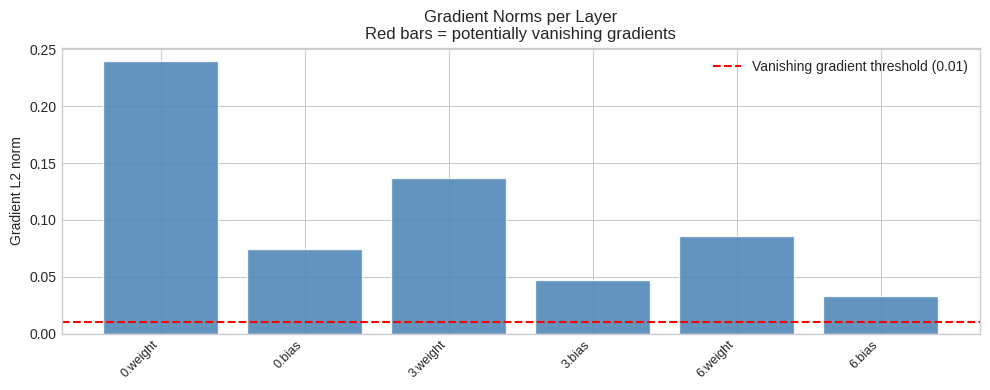

In [19]:
# ── Gradient flow visualisation ───────────────────────────────────────────────
def collect_grad_norms(model):
    norms = []
    for name, param in model.named_parameters():
        if param.grad is not None:
            norms.append((name, param.grad.norm().item()))
    return norms

# Run one more backward pass to get gradient norms
X_sample, y_sample = next(iter(train_loader))
X_sample, y_sample = X_sample.to(device), y_sample.to(device)

model.train()
optimizer.zero_grad()
loss_sample = criterion(model(X_sample), y_sample)
loss_sample.backward()
grad_norms = collect_grad_norms(model)

fig, ax = plt.subplots(figsize=(10, 4))
names_gn, norms_gn = zip(*grad_norms)
colors_gn = ['coral' if n < 0.01 else 'steelblue' for n in norms_gn]
ax.bar(range(len(names_gn)), norms_gn, color=colors_gn, alpha=0.85, edgecolor='white')
ax.axhline(0.01, color='red', linestyle='--', linewidth=1.5,
            label='Vanishing gradient threshold (0.01)')
ax.set_xticks(range(len(names_gn)))
ax.set_xticklabels(names_gn, rotation=45, ha='right', fontsize=9)
ax.set_title('Gradient Norms per Layer\nRed bars = potentially vanishing gradients')
ax.set_ylabel('Gradient L2 norm')
ax.legend()
plt.tight_layout()
plt.show()


## 10. Debugging Guide — The 10 Most Common PyTorch Errors

These are the errors every PyTorch beginner hits. Learn to recognise them instantly.


In [20]:
print('=== Common PyTorch Errors and Fixes ===')
print()

errors = [
    (
        '1. Shape mismatch in matmul',
        'RuntimeError: mat1 and mat2 shapes cannot be multiplied',
        'Check shapes. A @ B requires A.shape[-1] == B.shape[-2]',
        'Always print shapes before any @ operation: print(A.shape, B.shape)'
    ),
    (
        '2. Targets must be Long for CrossEntropyLoss',
        'RuntimeError: Expected target size to be... dtype torch.int64',
        'y = y.long()  or  torch.tensor(y, dtype=torch.long)',
        'Targets for classification must be int64, not float32'
    ),
    (
        '3. Gradients accumulate — forgot zero_grad()',
        'Gradients are 2x, 3x expected — model converges strangely',
        'optimizer.zero_grad() before EVERY loss.backward()',
        'Gradients add to .grad — never reset automatically'
    ),
    (
        '4. Cannot call backward on a non-leaf tensor in-place',
        'RuntimeError: a leaf Variable that requires grad has been used in an in-place operation',
        'Never do: param += 0.1  — use: param = param + 0.1  or use optimizer',
        'In-place ops on tracked tensors break the computation graph'
    ),
    (
        '5. Tensors on different devices',
        'RuntimeError: Expected all tensors to be on the same device',
        'X = X.to(device) and model = model.to(device)',
        'CPU tensor + CUDA tensor is illegal'
    ),
    (
        '6. NaN loss from start',
        'loss = nan from step 1',
        'Learning rate too large OR input data contains NaN/Inf',
        'Check: print(X.isnan().any()), try lr 10x smaller, add gradient clipping'
    ),
    (
        '7. Model not updating — forgot to call loss.backward() or optimizer.step()',
        'Loss stays constant',
        'Make sure training loop has: backward(), then optimizer.step()',
        'Also: make sure model is in .train() mode, not .eval()'
    ),
    (
        '8. Validation accuracy same as random — forgot model.eval()',
        'Val accuracy is wrong/noisy',
        'Call model.eval() before validation loop',
        'Dropout is active in train mode — predictions are stochastic'
    ),
    (
        '9. CUDA out of memory',
        'RuntimeError: CUDA out of memory',
        'Reduce batch_size, use gradient checkpointing, or del tensors and torch.cuda.empty_cache()',
        'Also: make sure you are using no_grad() during validation'
    ),
    (
        '10. Expected CrossEntropyLoss input shape mismatch',
        'ValueError: Expected input batch_size (N) to match target batch_size (M)',
        'Logits shape must be (batch, num_classes), targets shape must be (batch,)',
        'Common error: passing (batch,) logits — add output layer with correct n_classes'
    ),
]

for error, symptom, fix, note in errors:
    print(f'{'─'*70}')
    print(f'{error}')
    print(f'  Symptom: {symptom}')
    print(f'  Fix:     {fix}')
    print(f'  Note:    {note}')
print(f'{'─'*70}')


=== Common PyTorch Errors and Fixes ===

──────────────────────────────────────────────────────────────────────
1. Shape mismatch in matmul
  Symptom: RuntimeError: mat1 and mat2 shapes cannot be multiplied
  Fix:     Check shapes. A @ B requires A.shape[-1] == B.shape[-2]
  Note:    Always print shapes before any @ operation: print(A.shape, B.shape)
──────────────────────────────────────────────────────────────────────
2. Targets must be Long for CrossEntropyLoss
  Symptom: RuntimeError: Expected target size to be... dtype torch.int64
  Fix:     y = y.long()  or  torch.tensor(y, dtype=torch.long)
  Note:    Targets for classification must be int64, not float32
──────────────────────────────────────────────────────────────────────
3. Gradients accumulate — forgot zero_grad()
  Symptom: Gradients are 2x, 3x expected — model converges strangely
  Fix:     optimizer.zero_grad() before EVERY loss.backward()
  Note:    Gradients add to .grad — never reset automatically
─────────────────────

## 11. Exercises

**Exercise 1:** Implement `nn.Linear` completely from scratch — as an `nn.Module` subclass. It must:
- Store `W` and `b` as `nn.Parameter` (not plain tensors)
- Use He initialisation for `W`
- Implement `forward()` as `x @ W.T + b`
- Pass gradient checking against `nn.Linear` (same input, verify `dL/dW` and `dL/db` match)


In [21]:
# Your code here


In [22]:
# Solution
class LinearScratch(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        # nn.Parameter wraps a tensor and marks it as a learnable parameter
        self.weight = nn.Parameter(
            torch.randn(out_features, in_features) * (2.0 / in_features) ** 0.5
        )
        self.bias = nn.Parameter(torch.zeros(out_features))

    def forward(self, x):
        return x @ self.weight.T + self.bias

# Test: same weight/bias, same input -> same output and gradients
torch.manual_seed(0)
in_f, out_f = 4, 3

linear_scratch  = LinearScratch(in_f, out_f)
linear_official = nn.Linear(in_f, out_f)

# Copy weights to make comparison fair
with torch.no_grad():
    linear_official.weight.copy_(linear_scratch.weight)
    linear_official.bias.copy_(linear_scratch.bias)

x_ex1 = torch.randn(5, in_f)
y_ex1 = torch.randn(5, out_f)

# Forward
out_s = linear_scratch(x_ex1)
out_o = linear_official(x_ex1)
print(f'Output match: {torch.allclose(out_s, out_o)}')

# Backward
loss_s = F.mse_loss(out_s, y_ex1); loss_s.backward()
loss_o = F.mse_loss(out_o, y_ex1); loss_o.backward()

print(f'dL/dW match: {torch.allclose(linear_scratch.weight.grad, linear_official.weight.grad, atol=1e-6)}')
print(f'dL/db match: {torch.allclose(linear_scratch.bias.grad,   linear_official.bias.grad,   atol=1e-6)}')

# Show it's a proper nn.Module
print(f'\nnamed_parameters:')
for name, param in linear_scratch.named_parameters():
    print(f'  {name}: {param.shape}')


Output match: True
dL/dW match: True
dL/db match: True

named_parameters:
  weight: torch.Size([3, 4])
  bias: torch.Size([3])


**Exercise 2:** Build a training loop that **saves the best checkpoint** based on validation loss and **restores it** at the end of training. Implement:
- Save: `torch.save(model.state_dict(), 'best.pt')` when val_loss improves
- Load: `model.load_state_dict(torch.load('best.pt'))` after training
- Track `best_val_loss` and `patience` for early stopping (stop if val_loss doesn't improve for 10 epochs)
- Print which epoch the best model came from


In [23]:
# Your code here


In [24]:
# Solution
import os

torch.manual_seed(42)
model_ex2 = nn.Sequential(
    nn.Linear(20, 64), nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(64, 2)
).to(device)
optimizer_ex2 = optim.Adam(model_ex2.parameters(), lr=1e-3)

best_val_loss  = float('inf')
best_epoch     = 0
patience       = 10
patience_count = 0
ckpt_path      = '/tmp/best_model.pt'

for epoch in range(1, 101):
    # Train
    model_ex2.train()
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer_ex2.zero_grad()
        loss_ex = criterion(model_ex2(X_b), y_b)
        loss_ex.backward()
        optimizer_ex2.step()

    # Validate
    model_ex2.eval()
    val_loss_ex = 0.0
    with torch.no_grad():
        for X_b, y_b in val_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            val_loss_ex += criterion(model_ex2(X_b), y_b).item() * len(X_b)
    val_loss_ex /= len(val_set)

    # Checkpoint if improved
    if val_loss_ex < best_val_loss:
        best_val_loss  = val_loss_ex
        best_epoch     = epoch
        patience_count = 0
        torch.save(model_ex2.state_dict(), ckpt_path)
    else:
        patience_count += 1
        if patience_count >= patience:
            print(f'Early stopping at epoch {epoch}')
            break

# Restore best model
model_ex2.load_state_dict(torch.load(ckpt_path))
print(f'\nBest model from epoch {best_epoch} with val_loss={best_val_loss:.4f}')
print('Model restored to best checkpoint ✓')


Early stopping at epoch 77

Best model from epoch 67 with val_loss=0.9294
Model restored to best checkpoint ✓


**Exercise 3:** Implement a custom `nn.Module` for **Multi-Layer Perceptron** that:
- Accepts a `layer_dims` list (e.g. `[784, 512, 256, 10]`)
- Uses `nn.ModuleList` to store layers (not a plain Python list — learn why this matters)
- Applies BatchNorm after each hidden layer
- Applies Dropout after each hidden layer
- Supports a configurable activation function (`relu`, `gelu`, `tanh`)
- Implements a `get_activation_stats()` method that returns the mean and std of   activations at each layer (for the training dashboard)


In [25]:
# Your code here


In [26]:
# Solution
class ConfigurableMLP(nn.Module):
    def __init__(self, layer_dims, dropout=0.3, activation='relu'):
        super().__init__()
        act_map = {'relu': F.relu, 'gelu': F.gelu, 'tanh': torch.tanh}
        assert activation in act_map, f'activation must be one of {list(act_map)}'
        self.activation = act_map[activation]
        self.act_name   = activation

        # nn.ModuleList — registers all sub-modules so .parameters() finds them
        # Plain Python list would NOT register sub-modules!
        self.layers   = nn.ModuleList()
        self.bns      = nn.ModuleList()
        self.dropouts = nn.ModuleList()

        for i in range(len(layer_dims)-1):
            self.layers.append(nn.Linear(layer_dims[i], layer_dims[i+1]))
            if i < len(layer_dims)-2:  # no BN/dropout on output layer
                self.bns.append(nn.BatchNorm1d(layer_dims[i+1]))
                self.dropouts.append(nn.Dropout(dropout))

        self._activation_stats = []

    def forward(self, x):
        self._activation_stats = []
        for i, layer in enumerate(self.layers[:-1]):
            x = layer(x)
            x = self.bns[i](x)
            x = self.activation(x)
            x = self.dropouts[i](x)
            # Record stats (detach so we don't affect gradients)
            with torch.no_grad():
                self._activation_stats.append({
                    'layer': i, 'mean': x.mean().item(), 'std': x.std().item()
                })
        x = self.layers[-1](x)   # output layer — no activation/BN/dropout
        return x

    def get_activation_stats(self):
        return self._activation_stats

# Test
mlp_conf = ConfigurableMLP([20, 64, 32, 2], dropout=0.2, activation='gelu').to(device)
x_test_ex3 = torch.randn(16, 20).to(device)
mlp_conf.train()
out_ex3 = mlp_conf(x_test_ex3)
stats   = mlp_conf.get_activation_stats()

print(f'ConfigurableMLP output: {out_ex3.shape}')
print(f'Total params: {sum(p.numel() for p in mlp_conf.parameters()):,}')
print(f'\nActivation stats:')
for s in stats:
    print(f'  Layer {s["layer"]}: mean={s["mean"]:+.4f}  std={s["std"]:.4f}')

# Verify nn.ModuleList registers params correctly
plain_list_model = nn.Module()
plain_list_model.layers = [nn.Linear(4, 4), nn.Linear(4, 2)]  # plain Python list!
module_list_model = nn.Module()
module_list_model.layers = nn.ModuleList([nn.Linear(4, 4), nn.Linear(4, 2)])

print(f'\nPlain Python list params found:  {sum(p.numel() for p in plain_list_model.parameters())}')
print(f'nn.ModuleList params found:      {sum(p.numel() for p in module_list_model.parameters())}')
print('Always use nn.ModuleList/nn.ModuleDict — never plain Python lists!')


ConfigurableMLP output: torch.Size([16, 2])
Total params: 3,682

Activation stats:
  Layer 0: mean=+0.2810  std=0.6398
  Layer 1: mean=+0.2834  std=0.6435

Plain Python list params found:  0
nn.ModuleList params found:      30
Always use nn.ModuleList/nn.ModuleDict — never plain Python lists!


---

## 👨‍💻 Author

**Himanshu Kumar**

- 🌐 GitHub: [@himanshu231204](https://github.com/himanshu231204)
- 💼 LinkedIn: [himanshu231204](https://www.linkedin.com/in/himanshu231204)
- 🐦 Twitter/X: [@himanshu231204](https://twitter.com/himanshu231204)
- 📧 Email: himanshu231204@gmail.com
